# Lab 4.3: Model Diagnosis

In this lab you will implement the training set size experiment described in class, and also explore transfer learning using a pre-trained convolutional neural network (CNN) for image classification.

We will use the [Intel Image Classification dataset](https://www.kaggle.com/datasets/puneet6060/intel-image-classification).

In [5]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

url = "https://www.dropbox.com/scl/fi/7a69ka8kpdw40pm6uz91t/intel_image_classification.zip?rlkey=3knd7qsk6cvecw1mq7ohk39ot&dl=1"
archive = Path("intel_image_classification.zip")

if not archive.exists():
    print("Downloading dataset...")
    urlretrieve(url, archive)

if not Path("intel_image_classification").exists():
    print("Extracting dataset...")
    with ZipFile(archive) as zip_file:
        zip_file.extractall()

print("Dataset ready")

Dataset ready


In [6]:
import glob
import imageio
import skimage
from matplotlib import pyplot as plt
import numpy as np

import torch
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from tqdm import tqdm


Here is some code to load the dataset.

In [7]:
label_names = ['buildings','forest','glacier','mountain','sea','street']

In [8]:
def load_split(split):
    images = []
    labels = []
    for label in label_names:
        image_paths = sorted(glob.glob(f'intel_image_classification/seg_{split}/{label}/*.jpg'))
        for path in tqdm(image_paths, desc=f'Loading {split} images for {label}'):
            image = imageio.imread(path)
            if len(image.shape)<3:
                continue
            if image.shape[2]!=3:
                continue
            images.append(torch.tensor(image).permute(2,0,1))
            labels.append(label)
    return images, np.array(labels)

train_images, train_labels = load_split('train')
test_images, test_labels = load_split('test')

Loading train images for buildings:   0%|          | 0/2191 [00:00<?, ?it/s]C:\Users\CRNeu\AppData\Local\Temp\ipykernel_30768\1970331604.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(path)
Loading test images for street: 100%|██████████| 501/501 [00:02<00:00, 228.90it/s]


Text(0.5, 1.0, 'buildings')

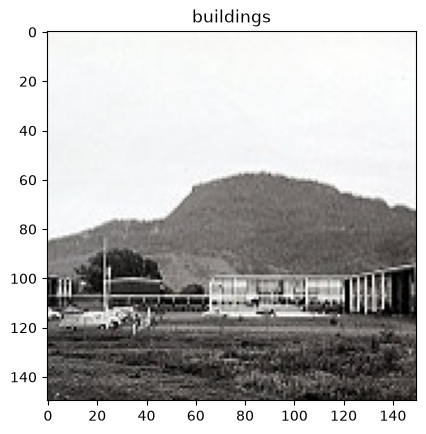

In [9]:
plt.imshow(train_images[0].permute(1,2,0))
plt.title(train_labels[0])

Here we randomly shuffle the training set, to support our later experiments.

In [10]:
inds = list(range(len(train_images)))
np.random.shuffle(inds)
train_images = [train_images[i] for i in inds]
train_labels = train_labels[inds]

Now we have arrays `train_images` and `train_labels` containing the images and labels for the training set, and the same for the test set.

Here we create a [MobileNetV2](https://arxiv.org/abs/1801.04381) model and download its pre-trained weights.  MobileNetV2 is a lightweight but high-performing convolutional neural network.  This version has been pre-trained on the ImageNet-1K dataset.

On Colab, go to `Runtime > Change Runtime Type` and select `T4 GPU` to make the CNN run faster.

In [11]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

weights = MobileNet_V2_Weights.IMAGENET1K_V2
mobilenet = mobilenet_v2(weights=weights)
# remove last layer
mobilenet.classifier = torch.nn.Sequential(*list(mobilenet.classifier.children())[:-1])
mobilenet = mobilenet.to(device)
mobilenet.eval()
transforms = weights.transforms()

This function will properly process the image and run MobileNetV2 to extract a feature vector.

In [12]:
def run_mobilenet(image):
    image = transforms(image)
    image = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = mobilenet(image)
    return output[0].cpu().numpy()

1. Compute a MobileNetV2 descriptor for each image to make two lists, `train_descriptors` and `test_descriptors`, using the `run_mobilenet` function from above.

In [13]:
# CODE GOE HERE
from tqdm import tqdm


train_descriptors = np.array([
    run_mobilenet(image)
    for image in tqdm(train_images, desc='Extracting train descriptors')
])

test_descriptors = np.array([
    run_mobilenet(image)
    for image in tqdm(test_images, desc='Extracting test descriptors')
])

Extracting test descriptors: 100%|██████████| 3000/3000 [01:31<00:00, 32.61it/s]


2. Build a k-nearest neighbors classifier on the training set (```sklearn.neighbors.KNeighborsClassifier```).

This model will find the $k$ nearest neighbors to the query point and output the most common label.  Use $k=10$.

Run the model on the training and testing sets and print out the accuracy score for each (```sklearn.metrics.accuracy_score``` or simply use ```model.score```).

In [14]:
# CODE GOES HERE

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(train_descriptors, train_labels)

train_accuracy = knn.score(train_descriptors, train_labels)
test_accuracy = knn.score(test_descriptors, test_labels)

print(f'Train accuracy: {train_accuracy:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Train accuracy: 0.9214
Test accuracy: 0.9177


3. Now let's explore how train and test accuracy change as training set size increases.

We will test a range of training set sizes in increments of 1000 (so 1000, 2000, 3000, ... up to the original size of the training set).

For each size setting $s$, fit a ```kNeighborsClassifer``` model to the first $s$ examples in the training set.   Use $k=10$.

Then compute the accuracy of the model on the chosen subset of the training set, and the entire test set.  *Note: always use the entire test set!*


In [15]:
# CODE GOES HERE
s = list(range(1000, len(train_descriptors) + 1, 1000))

train_accuracies = []
test_accuracies = []

for n in tqdm(s, desc='Evaluating KNN on increasing training set sizes'):
    knn = KNeighborsClassifier(n_neighbors=10)
    knn.fit(train_descriptors[:n], train_labels[:n])
    
    train_accuracy = knn.score(train_descriptors[:n], train_labels[:n])
    test_accuracy = knn.score(test_descriptors, test_labels)
    
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

for n, train_acc, test_acc in zip(s, train_accuracies, test_accuracies):
    print(f'Training size: {n}, Train accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}')

Evaluating KNN on increasing training set sizes: 100%|██████████| 14/14 [00:37<00:00,  2.65s/it]

Training size: 1000, Train accuracy: 0.9050, Test accuracy: 0.8870
Training size: 2000, Train accuracy: 0.9135, Test accuracy: 0.8940
Training size: 3000, Train accuracy: 0.9150, Test accuracy: 0.8970
Training size: 4000, Train accuracy: 0.9117, Test accuracy: 0.9047
Training size: 5000, Train accuracy: 0.9158, Test accuracy: 0.9063
Training size: 6000, Train accuracy: 0.9208, Test accuracy: 0.9027
Training size: 7000, Train accuracy: 0.9191, Test accuracy: 0.9043
Training size: 8000, Train accuracy: 0.9204, Test accuracy: 0.9023
Training size: 9000, Train accuracy: 0.9184, Test accuracy: 0.9063
Training size: 10000, Train accuracy: 0.9201, Test accuracy: 0.9093
Training size: 11000, Train accuracy: 0.9205, Test accuracy: 0.9130
Training size: 12000, Train accuracy: 0.9212, Test accuracy: 0.9137
Training size: 13000, Train accuracy: 0.9206, Test accuracy: 0.9130
Training size: 14000, Train accuracy: 0.9216, Test accuracy: 0.9183


Make a plot of the two accuracy values as the training set size increases.  Put both lines on the same plot.

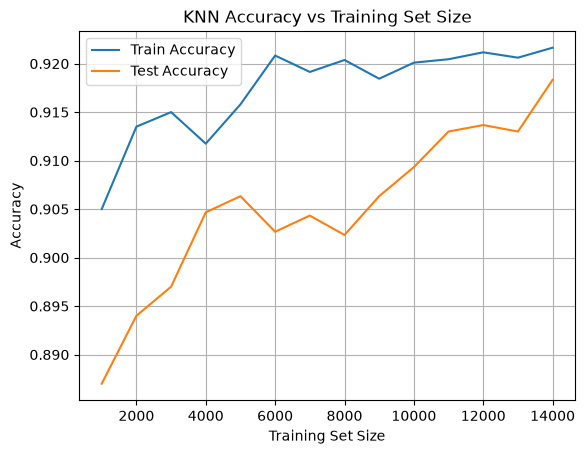

In [16]:
# CODE GOES HERE

import matplotlib.pyplot as plt

plt.plot(s, train_accuracies, label='Train Accuracy')
plt.plot(s, test_accuracies, label='Test Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs Training Set Size')
plt.legend()
plt.grid()
plt.show()

Analyze the results.  If we want to improve the model's test set accuracy, what should we do -- add more training data, or choose a different model?

As training set size increaes, test accuracy improves at first but starts to plateau. Train and test accuracies are also very close indicating that overfitting isnt present. Thus, to improve we should use a different model that is better for this given data or fine tune the neural network.